
image 1/1 e:\designs\ANN-Project\Artificial-Neural-Networks-Project-Dead-Neurons-\Images_for_testing\test_image32.jpg: 640x320 26 Cardboards, 1 Metal, 3 Organics, 8 Plasticss, 75.4ms
Speed: 5.9ms preprocess, 75.4ms inference, 6.9ms postprocess per image at shape (1, 3, 640, 320)


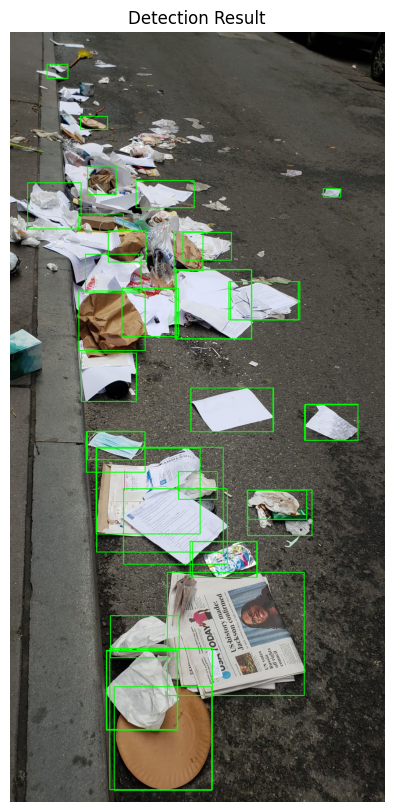

In [39]:
from ultralytics import YOLO
import cv2
import os
import matplotlib.pyplot as plt

# Load trained model
model = YOLO("YOLOv8m/runs/detect/garbage_detection_test/weights/best.pt")

# Image path
image_path = "Images_for_testing/test_image32.jpg"

# Predict
results = model(image_path, conf=0.158)

# Get original image name without extension
image_name = os.path.splitext(os.path.basename(image_path))[0]

# Create main crop folder
# main_crop_dir = "crops"

# Create subfolder using original image name
# image_crop_dir = os.path.join(main_crop_dir, image_name)

# os.makedirs(image_crop_dir, exist_ok=True)

# Process detections
for r in results:

    boxes = r.boxes

    # Original image
    img = r.orig_img.copy()

    for i, box in enumerate(boxes):

        # Bounding box coordinates
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # Confidence
        conf = float(box.conf[0])

        # Class ID
        cls_id = int(box.cls[0])

        # Class name
        cls_name = model.names[cls_id]

        # Crop object
        crop = img[y1:y2, x1:x2]

        # Save crop inside image-specific folder
        # filename = f"{cls_name}_{i}_{conf:.2f}.jpg"
        # filepath = os.path.join(image_crop_dir, filename)

        # cv2.imwrite(filepath, crop)

        # print(f"Saved: {filepath}")

        # Draw ONLY bounding box (no class name)
        cv2.rectangle(
            img,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),   # Green color
            2              # Thickness
        )

    # Convert BGR to RGB for matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Show final image
    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title("Detection Result")
    plt.show()